In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Funkcja Ackleya jednowymiarowa:
$$
f(x) = -20 \exp\!\left(-0.2 \sqrt{x^{2}}\right)
        - \exp\!\left(\cos(2\pi x)\right)
        + 20 + e
$$

### Gradient:
$$
f'(x)
=
4x \frac{\exp(-0.2\sqrt{x^{2}})}{\sqrt{x^{2}}}
+
2\pi \sin(2\pi x)\, \exp\!\left(\cos(2\pi x)\right)
=
4\,\operatorname{sign}(x)\,e^{-0.2|x|}
+
2\pi \sin(2\pi x)\,\exp\!\left(\cos(2\pi x)\right)
$$
bez dzielenia przez 0

In [11]:
def f_ackley_1d(x):
    x = np.array(x, dtype=float)
    return -20 * np.exp(-0.2 * np.sqrt(x**2)) - np.exp(np.cos(2*np.pi*x)) + 20 + np.e

def grad_ackley_1d(x):
    x = np.array(x, dtype=float)
    term1 = 4 * np.sign(x) * np.exp(-0.2 * np.abs(x))
    term2 = 2 * np.pi * np.sin(2 * np.pi * x) * np.exp(np.cos(2 * np.pi * x))
    return term1 + term2

## Funkcja Ackleya dwuwymiarowa:
$$
f(x,y) = -20 \exp\!\left(-0.2 \sqrt{\frac{x^{2} + y^{2}}{2}}\right)
         - \exp\!\left(
             \frac{\cos(2\pi x) + \cos(2\pi y)}{2}
         \right)
         + 20 + e
$$

Oznaczamy:

$$
r = \sqrt{\frac{x^{2} + y^{2}}{2}}, 
\qquad
A = \frac{\cos(2\pi x) + \cos(2\pi y)}{2}
$$

### Gradient:

$$
\nabla f(x,y)
=
\begin{bmatrix}
-20 e^{-0.2 r}\left(-0.2\,\frac{x}{2r}\right)
+
\pi \sin(2\pi x)\, e^{A}
\\[10pt]
-20 e^{-0.2 r}\left(-0.2\,\frac{y}{2r}\right)
+
\pi \sin(2\pi y)\, e^{A}
\end{bmatrix}
$$

In [12]:
def f_ackley_2d(v):
    x, y = v 
    r = np.sqrt((x**2 + y**2) / 2)
    A = (np.cos(2*np.pi*x) + np.cos(2*np.pi*y)) / 2
    return -20 * np.exp(-0.2 * r) - np.exp(A) + 20 + np.e

def grad_ackley_2d(v):
    x, y = v
    r = np.sqrt((x**2 + y**2) / 2)
    A = (np.cos(2*np.pi*x) + np.cos(2*np.pi*y)) / 2
    #dzielenie przez zero
    if r == 0:
        fx_rad = 0
        fy_rad = 0
    else:
        fx_rad = -20 * np.exp(-0.2 * r) * (-0.2 * x / (2*r))
        fy_rad = -20 * np.exp(-0.2 * r) * (-0.2 * y / (2*r))
    fx = fx_rad + np.pi * np.sin(2*np.pi*x) * np.exp(A)
    fy = fy_rad + np.pi * np.sin(2*np.pi*y) * np.exp(A)
    return np.array([fx, fy])

## Algorytm gradientu prostego (Gradient Descent)
$$x_{k+1} = x_k - \alpha \cdot \nabla f(x_k)$$

In [13]:
def GD_const_alpha(f, grad_f, x0, eps, alpha, max_iter=1000):
    #f - funkcja celu, której minimum szukamy
    #grad_f - gradient funkcji celu, do wyznaczednia kierunku spadku
    #x0 - punkt startowy
    #eps - tolerancja, kiedy zatrzymać algorytm
    #alpha - stały krok, jak duży krok wykonujemy
    #max_iter - maksymalna liczba iteracji

    x_k = np.array(x0, dtype=float)
    lista_x = [x_k.copy()] #kolejne punkty GD
    lista_f = [f(x_k)] #wartosci funkcji

    for _ in range(max_iter):
        grad_k = grad_f(x_k)
        if np.linalg.norm(grad_k) <= eps: # warunek stopu - norma gradientu
            break
        x_k = x_k - alpha * grad_k #krok GD, w kierunku przeciwnym do gradientu
        lista_x.append(x_k.copy())
        lista_f.append(f(x_k))

    return x_k, lista_x, lista_f
    #x_k - przybliżone minimum po wykonaniu algorytmu
    #lista_x - lista kolejnych punktów odwiedzonych przez algorytm
    #lista_f - lista wartości funkcji celu w kolejnych punktach

## Minimum funkcji Ackleya

In [ ]:
x0 = [2.0]       
alpha = 0.01
eps = 1e-6

xmin_1d, traj_x_1d, traj_f_1d = GD_const_alpha(f_ackley_1d, grad_ackley_1d, x0, eps, alpha)
print("Minimum 1D =", xmin_1d)
print("f(min) =", f_ackley_1d(xmin_1d))


Minimum 1D = [1.97445199]
f(min) = [6.55964538]


In [48]:
x0 = [1.0, 1.0]     
alpha = 0.01
eps = 1e-6

xmin_2d, traj_x_2d, traj_f_2d = GD_const_alpha(f_ackley_2d, grad_ackley_2d, x0, eps, alpha)
print("Minimum 2D =", xmin_2d)
print("f(min) =", f_ackley_2d(xmin_2d))


Minimum 2D = [0.96847767 0.96847767]
f(min) = 3.5744518772576837


## Wpływ rozmiaru kroku na działanie algorytmu

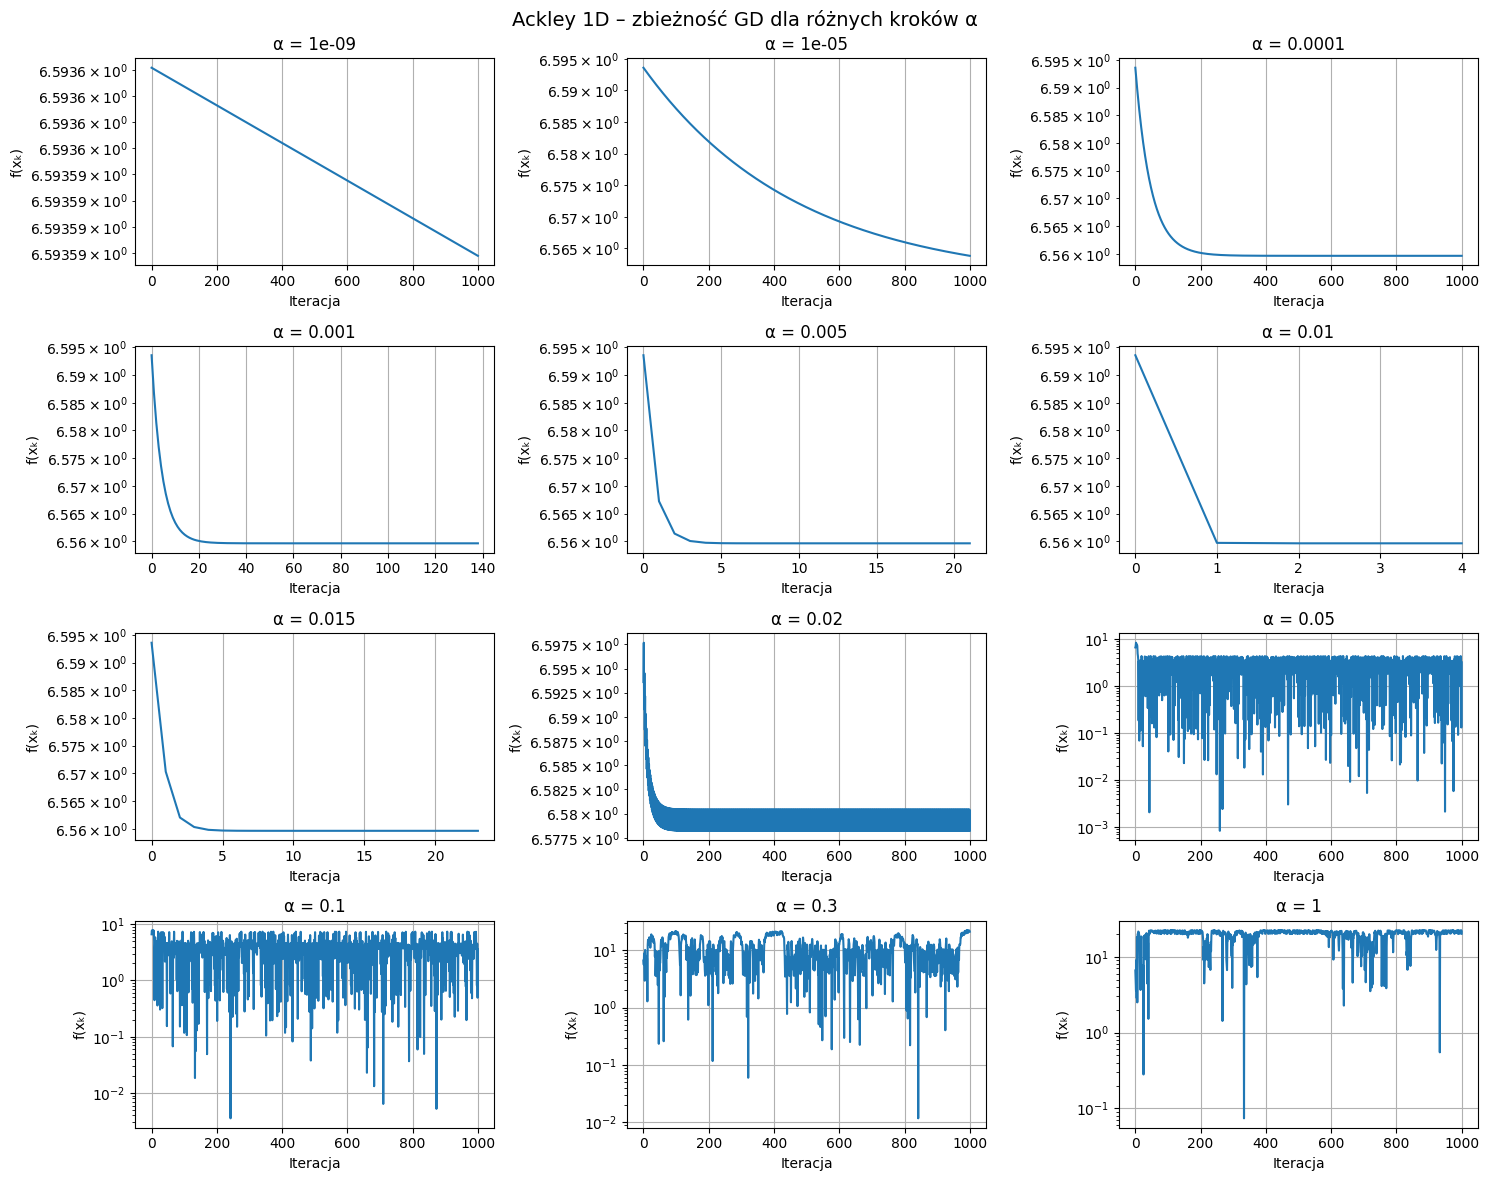

           alpha  iterations      x_min   f(x_min)
0   1.000000e-09        1001   1.999997   6.593592
1   1.000000e-05        1001   1.983483   6.563825
2   1.000000e-04        1001   1.974453   6.559645
3   1.000000e-03         139   1.974452   6.559645
4   5.000000e-03          22   1.974452   6.559645
5   1.000000e-02           5   1.974452   6.559645
6   1.500000e-02          24   1.974452   6.559645
7   2.000000e-02        1001   1.993397   6.578220
8   5.000000e-02        1001  -0.304790   3.187469
9   1.000000e-01        1001  -0.966769   3.574595
10  3.000000e-01        1001 -22.824044  20.943882
11  1.000000e+00        1001  97.053690  20.148973


In [39]:
x0 = 2.0
eps = 1e-6
alphas = [0.000000001, 0.00001,0.0001, 0.001, 0.005, 0.01, 0.015, 0.02, 0.05, 0.1, 0.3, 1]   

n = len(alphas)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
axes = axes.flatten()
results = []
for i, a in enumerate(alphas):
    x_min, traj_x, traj_f = GD_const_alpha(f_ackley_1d, grad_ackley_1d, x0, eps, a)
    results.append([a, len(traj_f), x_min, traj_f[-1]])
    ax = axes[i]
    ax.plot(traj_f)
    ax.set_title(f"α = {a}")
    ax.set_xlabel("Iteracja")
    ax.set_ylabel("f(xₖ)")
    ax.set_yscale("log")
    ax.grid(True)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Ackley 1D – zbieżność GD dla różnych kroków α", fontsize=14)
plt.tight_layout()
plt.show()
df = pd.DataFrame(results, columns=["alpha", "iterations", "x_min", "f(x_min)"])
print(df)

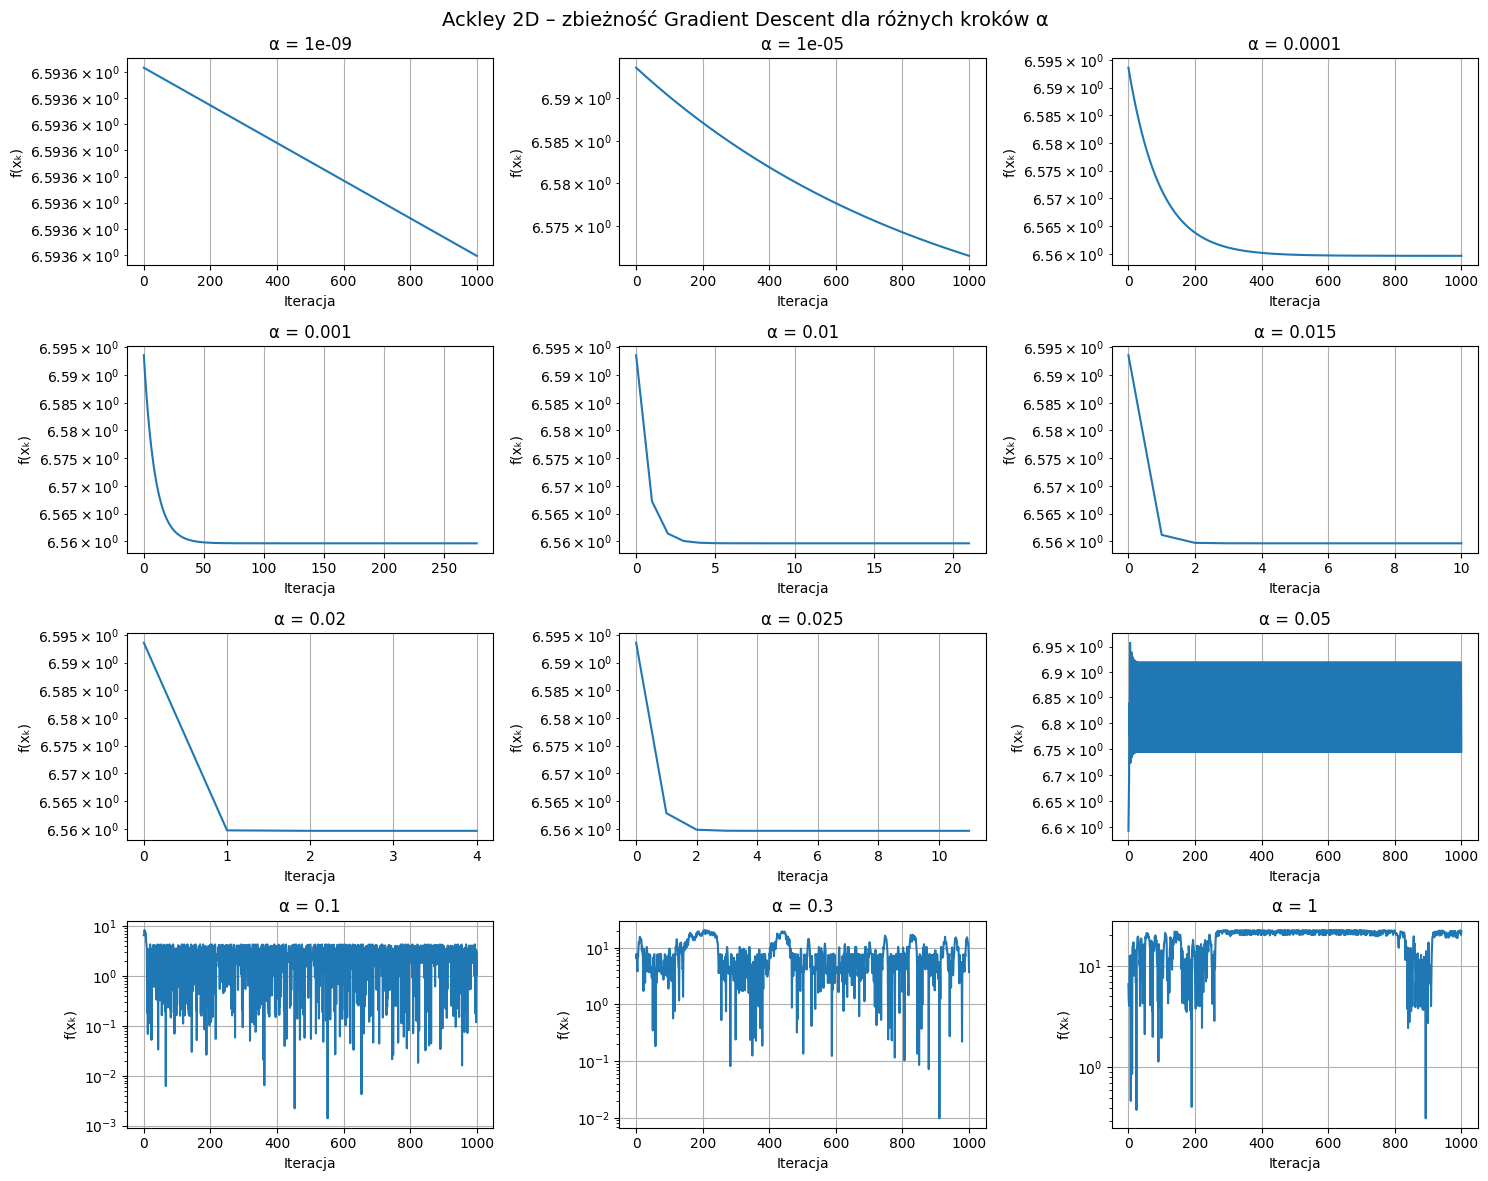

           alpha  iterations                                         x_min  \
0   1.000000e-09        1001      [1.9999986593956591, 1.9999986593956591]   
1   1.000000e-05        1001      [1.9896059109671838, 1.9896059109671838]   
2   1.000000e-04        1001      [1.9746042024268617, 1.9746042024268617]   
3   1.000000e-03         278        [1.974452000049578, 1.974452000049578]   
4   1.000000e-02          22      [1.9744519949410944, 1.9744519949410944]   
5   1.500000e-02          11      [1.9744520002188415, 1.9744520002188415]   
6   2.000000e-02           5      [1.9744519888928245, 1.9744519888928245]   
7   2.500000e-02          12      [1.9744519730344423, 1.9744519730344423]   
8   5.000000e-02        1001      [2.0338331884989342, 2.0338331884989342]   
9   1.000000e-01        1001  [-0.11606162245044671, -0.11606162245044671]   
10  3.000000e-01        1001      [0.3814956565491139, 0.3814956565491139]   
11  1.000000e+00        1001    [-33.749212816250875, -33.749212

In [ ]:
x0 = np.array([2.0, 2.0])
eps = 1e-6
alphas = [0.000000001, 0.00001, 0.0001, 0.001, 0.01, 0.015, 0.02, 0.025, 0.05, 0.1, 0.3, 1]   

n = len(alphas)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
axes = axes.flatten()
results = []
for i, a in enumerate(alphas):
    x_min, traj_x, traj_f = GD_const_alpha(f_ackley_2d, grad_ackley_2d, x0, eps, a)
    results.append([a, len(traj_f), x_min, traj_f[-1]])
    ax = axes[i]
    ax.plot(traj_f)
    ax.set_title(f"α = {a}")
    ax.set_xlabel("Iteracja")
    ax.set_ylabel("f(xₖ)")
    ax.set_yscale("log")
    ax.grid(True)
for j in range(i+1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Ackley 2D – zbieżność Gradient Descent dla różnych kroków α", fontsize=14)
plt.tight_layout()
plt.show()
df = pd.DataFrame(results, columns=["alpha", "iterations", "x_min", "f(x_min)"])
print(df)
print(df)

## Wpływ wyboru punktu startowego 

     x0 x_min_found  f(x_min_found)  iterations
0  -4.0   -3.983068    1.099826e+01           6
1  -3.5   -2.979224    9.001093e+00          15
2  -3.0   -2.979224    9.001093e+00           6
3  -2.5   -1.974452    6.559645e+00          14
4  -2.0   -1.974452    6.559645e+00           5
5  -1.5   -0.968478    3.574452e+00          13
6  -1.0   -0.968478    3.574452e+00           5
7  -0.5    0.040789    2.498436e-01        1001
8   0.0         0.0    4.440892e-16           1
9   0.5   -0.040789    2.498436e-01        1001
10  1.0    0.968478    3.574452e+00           5
11  1.5    0.968478    3.574452e+00          13
12  2.0    1.974452    6.559645e+00           5
13  2.5    1.974452    6.559645e+00          14
14  3.0    2.979224    9.001093e+00           6
15  3.5    2.979224    9.001093e+00          15
16  4.0    3.983068    1.099826e+01           6


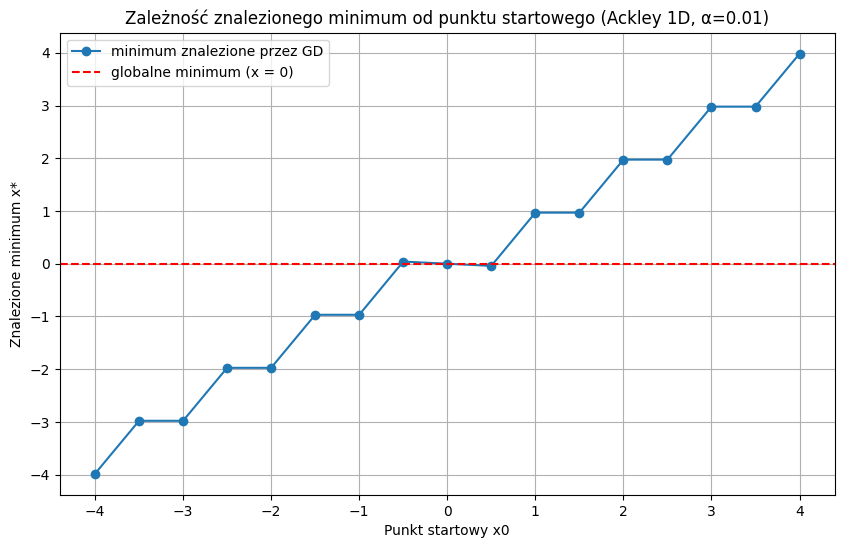

In [45]:
alpha = 0.01
eps = 1e-6
start_points = np.linspace(-4, 4, 17)  

results = []
for x0 in start_points:
    xmin, traj_x, traj_f = GD_const_alpha(f_ackley_1d, grad_ackley_1d, x0, eps, alpha)
    results.append([x0, xmin, f_ackley_1d(xmin), len(traj_f)])
df = pd.DataFrame(results, columns=["x0", "x_min_found", "f(x_min_found)", "iterations"])
print(df)
plt.figure(figsize=(10,6))
plt.plot(df["x0"], df["x_min_found"], "o-", label="minimum znalezione przez GD")
plt.axhline(0, color="red", linestyle="--", label="globalne minimum (x = 0)")
plt.title("Zależność znalezionego minimum od punktu startowego (Ackley 1D, α=0.01)")
plt.xlabel("Punkt startowy x0")
plt.ylabel("Znalezione minimum x*")
plt.grid(True)
plt.legend()
plt.show()